In [1]:
#importing usefull library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpmath import mp
from scipy import optimize
from scipy import stats
from scipy.optimize import minimize
from IPython.display import display, Math
import matplotlib as mpl
%matplotlib inline

In [2]:
test = pd.read_csv('test.csv')
retest = pd.read_csv('retest.csv')
test.head()

,Sesso,Mesi,COMPRENSIONE_FRASI,COMPRENSIONE_PAROLE,PAROLE_PRODOTTE,AZIONI_E_GESTI,Scala_Assertività,Scala_Responsività
0,M,24,10-25,25-50,50-75,10-25,2,2
1,F,29,90-95,75-90,90-95,75-90,3,3
2,F,15,75-90,90-95,75-90,50-75,2,2
3,M,21,10-25,50-75,25-50,25-50,2,2
4,F,21,25-50,10-25,10-25,75-90,2,3


In [3]:
# -------------------------
# FUNZIONI PER COSTRUIRE OGNI PANNELLO
# -------------------------
def prepara(df, colonna):
    """
    Pulisce e prepara i dati mantenendo TUTTI i bambini
    tranne quelli con Nan nella colonna analizzata.
    I bambini presenti nel dataset vengono SEMPRE mantenuti nello stack.
    """

    df = df.copy()
    df["Mesi"] = pd.to_numeric(df["Mesi"], errors="coerce")

    # Normalizzazione stringhe
    df[colonna] = (
        df[colonna]
        .astype(str)
        .str.strip()
        .replace({"Nan": np.nan, "nan": np.nan, "NaN": np.nan})
    )

    # I NaN NON si droppano → li marchiamo
    df[colonna] = df[colonna].fillna("mancante")

    # Ordine logico
    ordine_bin = ["<5", "5-10", "10-25", "25-50",
                  "50-75", "75-90", "90-95", "95", "mancante"]

    presenti = df[colonna].unique().tolist()

    # mantiene solo i bin realmente presenti nei dati
    bins_labels = [b for b in ordine_bin if b in presenti]

    # Costruzione stack per sesso
    sesso_groups = []
    for sesso in ["F", "M"]:
        subset = df[df["Sesso"] == sesso]
        data_stacked = []
        for bin_label in bins_labels:
            mesi_bin = subset[subset[colonna] == bin_label]["Mesi"].dropna().values
            mesi_bin_sorted = np.sort(mesi_bin)[::-1]   # colore per mesi
            data_stacked.append(mesi_bin_sorted)
        sesso_groups.append((sesso, data_stacked))

    return df, bins_labels, sesso_groups





def calcola_epsilon(test_df, retest_df, colonna):
    """
    Calcola la percentuale di miglioramento epsilon per F e M.
    """

    # Valori medi dei bin
    peso_bin = {
        "<5": 2.5,
        "5-10": 7.5,
        "10-25": 17.5,
        "25-50": 37.5,
        "50-75": 62.5,
        "75-90": 82.5,
        "90-95": 92.5,
        "95": 97.5
    }

    eps_sesso = {}

    for sesso in ["F", "M"]:

        test_s = test_df[test_df["Sesso"] == sesso]
        retest_s = retest_df[retest_df["Sesso"] == sesso]

        # Conta quanti soggetti per bin
        count_test = test_s.groupby(colonna).size()
        count_retest = retest_s.groupby(colonna).size()

        # Bin presenti in entrambi i dataset
        tutti_bin = sorted(set(count_test.index).union(count_retest.index))

        somma = 0
        for b in tutti_bin:
            n_test = count_test.get(b, 0)
            n_retest = count_retest.get(b, 0)
            diff = n_retest - n_test

            w = peso_bin[b] if b in peso_bin else 0
            somma += diff * w

        # N totale per sesso
        Ntot = len(test_s)

        epsilon = somma / (Ntot * 95)

        eps_sesso[sesso] = epsilon

    return eps_sesso

def plot_panel(ax_row, sesso_groups, bins_labels, titolo_riga,
                      test_df, retest_df, colonna, cmap, norm):
    """
    Stampa una riga di due pannelli (F/M), centrando il titolo e
    mantenendo tutti i bambini (eccetto Nan → "Dato assente").
    """

    x = np.arange(len(bins_labels))
    fig = ax_row[0].get_figure()

    # ----- titolo centrato -----
    left = min(ax.get_position().x0 for ax in ax_row)
    right = max(ax.get_position().x1 for ax in ax_row)
    center_x = (left + right) / 2 -0.08

    top_y = max(ax.get_position().y1 for ax in ax_row) + 0.015

    fig.text(center_x, top_y, titolo_riga,
             ha="center", va="bottom",
             fontsize=18, fontweight="bold")

    # ----- epsilon -----
    epsilon = calcola_epsilon(test_df, retest_df, colonna)

    # ----- pannelli F / M -----
    for (label, data_stacked), idx in zip(sesso_groups, range(len(ax_row))):

        ax = ax_row[idx]
        mesi_totali = []

        for bin_idx, mesi_bin_sorted in enumerate(data_stacked):
            mesi_totali.extend(mesi_bin_sorted)
            bottom = 0
            for mese in mesi_bin_sorted:
                ax.bar(
                    bin_idx, 1, width=0.6, bottom=bottom,
                    color=cmap(norm(mese)), edgecolor="black"
                )
                bottom += 1

        ax.set_title(label)
        ax.set_xticks(x)
        ax.set_xticklabels(bins_labels, rotation=45)
        ax.grid(axis='y', linestyle=":", alpha=0.6)

        if idx == 0:
            ax.set_ylabel("Numero di bambini")

        # mostra epsilon solo nei RETEST
        if titolo_riga == "RETEST":
            ax.text(
                0.5, -0.13, f"ε = {epsilon[label]:.3f}",
                transform=ax.transAxes,
                ha="center", va="top",
                fontsize=12,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
            )


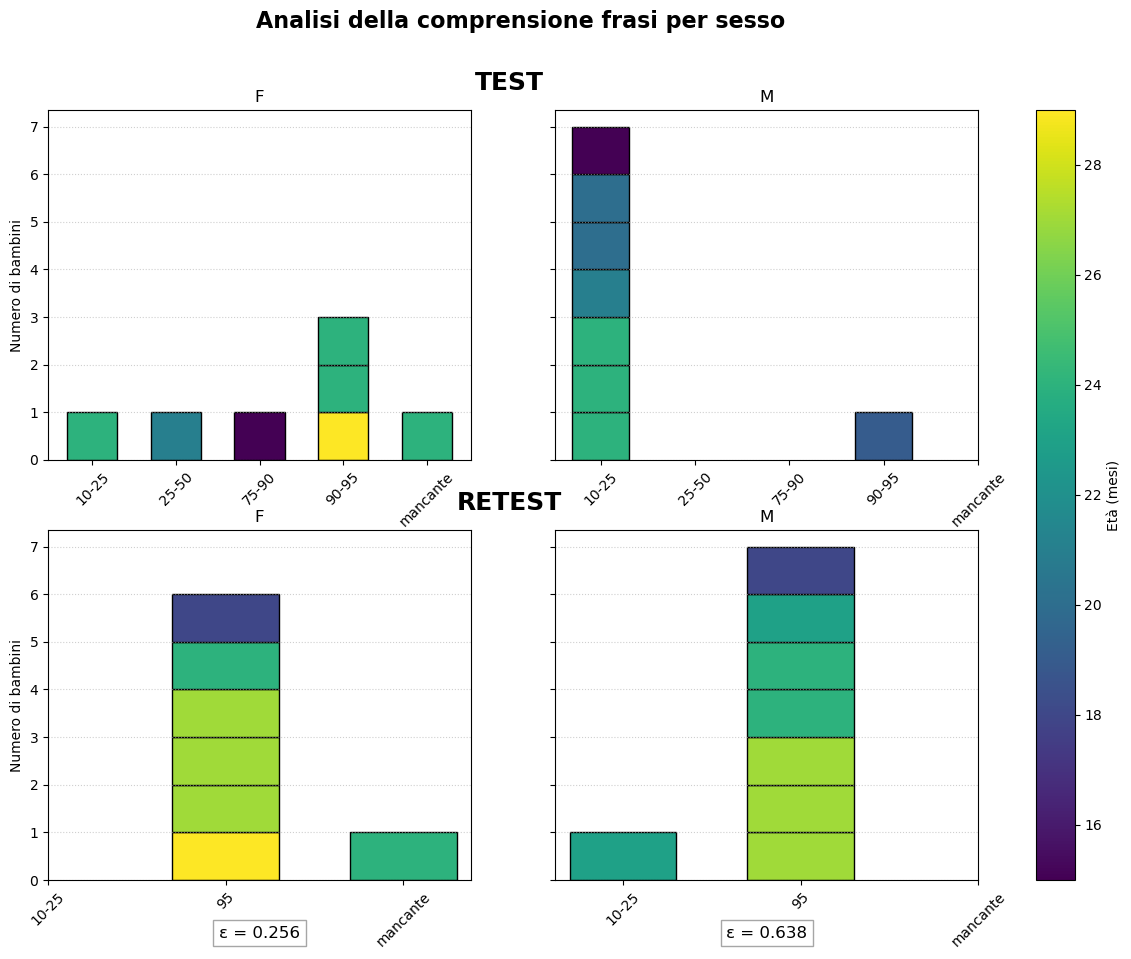

In [4]:
colonna = "COMPRENSIONE_FRASI"   # <--- CAMBIA SOLO QUESTO
cmap_name = "viridis"

# =======================
# PREPARA TEST E RETEST
# =======================

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
cmap = plt.get_cmap(cmap_name)


test_clean, bins_test, sesso_test = prepara(test, colonna)
norm = mpl.colors.Normalize(vmin=test_clean["Mesi"].min(), vmax=test_clean["Mesi"].max())

retest_clean, bins_retest, sesso_retest = prepara(retest, colonna)

plot_panel(axes[0], sesso_test, bins_test, "TEST",
                  test_clean, retest_clean, colonna, cmap, norm)

plot_panel(axes[1], sesso_retest, bins_retest, "RETEST",
                  test_clean, retest_clean, colonna, cmap, norm)

# colorbar
# TITOLO GENERALE 
fig.suptitle("Analisi della " + colonna.lower().replace('_', ' ') + " per sesso", fontsize=16, fontweight='bold', x = 0.5-0.06)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="vertical")
cbar.set_label("Età (mesi)")
import os

# Crea la cartella se non esiste
os.makedirs('grafici0', exist_ok=True)

# Salva il grafico
plt.savefig(f'grafici0/analisi_{colonna}.png', dpi=300, bbox_inches='tight')

plt.show()


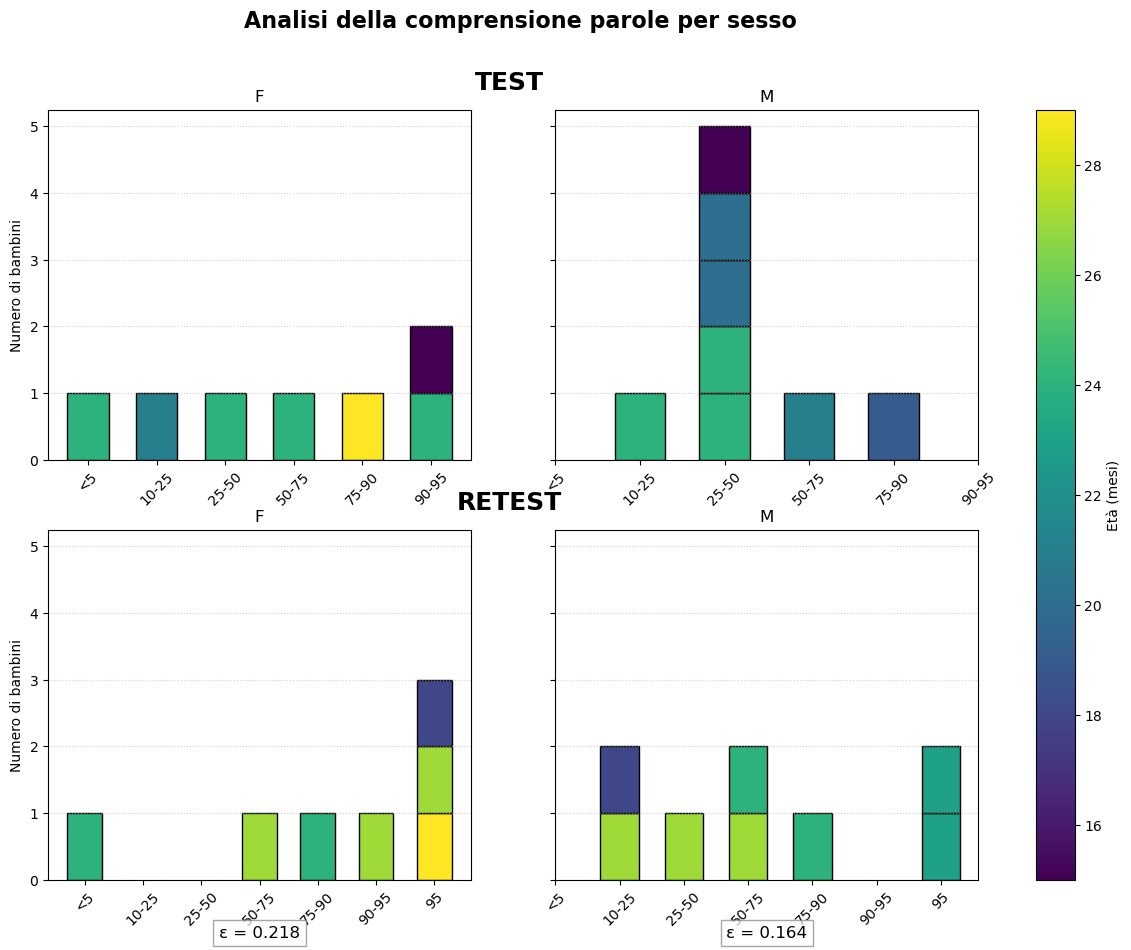

In [5]:
colonna = "COMPRENSIONE_PAROLE"   # <--- CAMBIA SOLO QUESTO
cmap_name = "viridis"


# =======================
# PREPARA TEST E RETEST
# =======================

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
cmap = plt.get_cmap(cmap_name)
norm = mpl.colors.Normalize(vmin=test_clean["Mesi"].min(), vmax=test_clean["Mesi"].max())


test_clean, bins_test, sesso_test = prepara(test, colonna)
retest_clean, bins_retest, sesso_retest = prepara(retest, colonna)

plot_panel(axes[0], sesso_test, bins_test, "TEST",
                  test_clean, retest_clean, colonna, cmap, norm)

plot_panel(axes[1], sesso_retest, bins_retest, "RETEST",
                  test_clean, retest_clean, colonna, cmap, norm)

# colorbar

fig.suptitle("Analisi della " + colonna.lower().replace('_', ' ') + " per sesso", fontsize=16, fontweight='bold', x = 0.5-0.06)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="vertical")
cbar.set_label("Età (mesi)")

# Crea la cartella se non esiste
os.makedirs('grafici0', exist_ok=True)

# Salva il grafico
plt.savefig(f'grafici0/analisi_{colonna}.png', dpi=300, bbox_inches='tight')

plt.show()


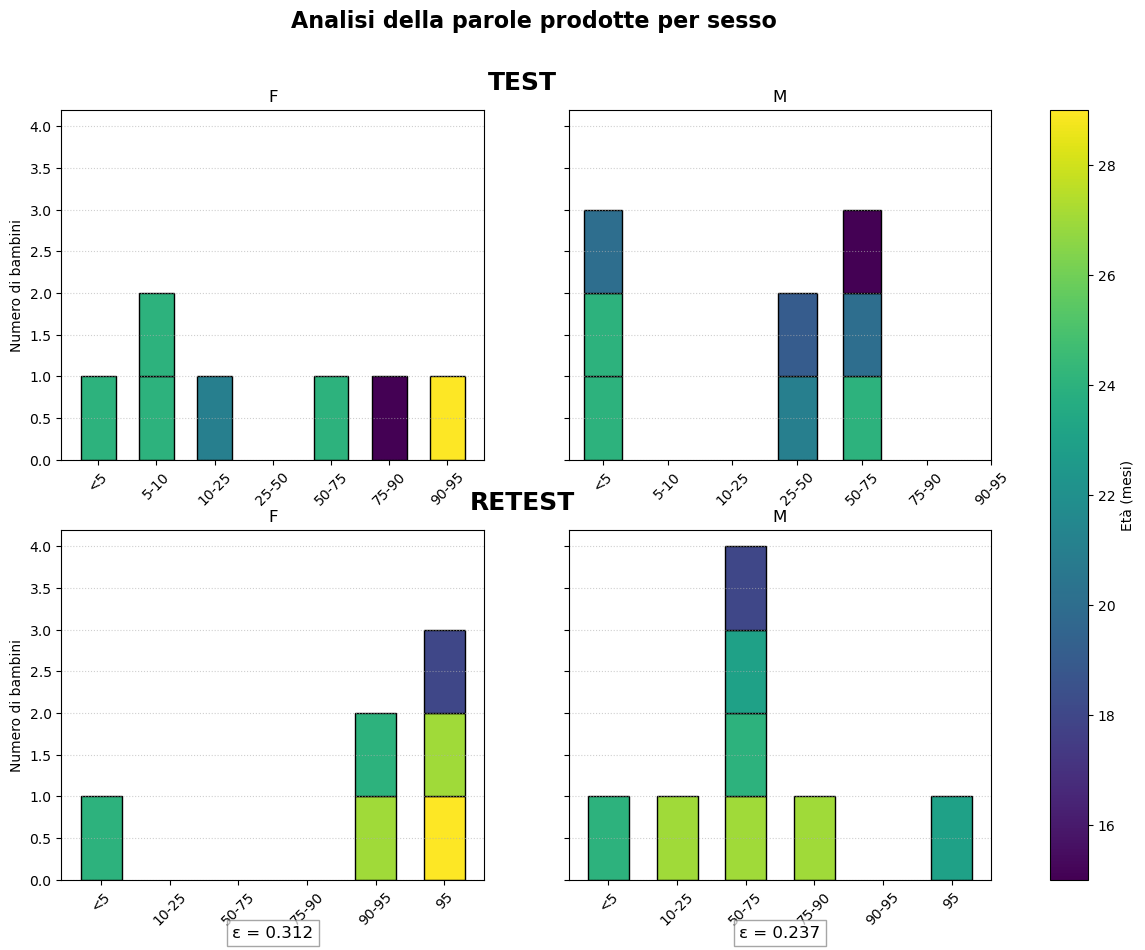

In [6]:
colonna = "PAROLE_PRODOTTE"   # <--- CAMBIA SOLO QUESTO
cmap_name = "viridis"

# =======================
# PREPARA TEST E RETEST
# =======================

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
cmap = plt.get_cmap(cmap_name)
norm = mpl.colors.Normalize(vmin=test_clean["Mesi"].min(), vmax=test_clean["Mesi"].max())


test_clean, bins_test, sesso_test = prepara(test, colonna)
retest_clean, bins_retest, sesso_retest = prepara(retest, colonna)

plot_panel(axes[0], sesso_test, bins_test, "TEST",
                  test_clean, retest_clean, colonna, cmap, norm)

plot_panel(axes[1], sesso_retest, bins_retest, "RETEST",
                  test_clean, retest_clean, colonna, cmap, norm)

# colorbar

fig.suptitle("Analisi della " + colonna.lower().replace('_', ' ') + " per sesso", fontsize=16, fontweight='bold', x = 0.5-0.06)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="vertical")
cbar.set_label("Età (mesi)")

# Crea la cartella se non esiste
os.makedirs('grafici0', exist_ok=True)

# Salva il grafico
plt.savefig(f'grafici0/analisi_{colonna}.png', dpi=300, bbox_inches='tight')

plt.show()

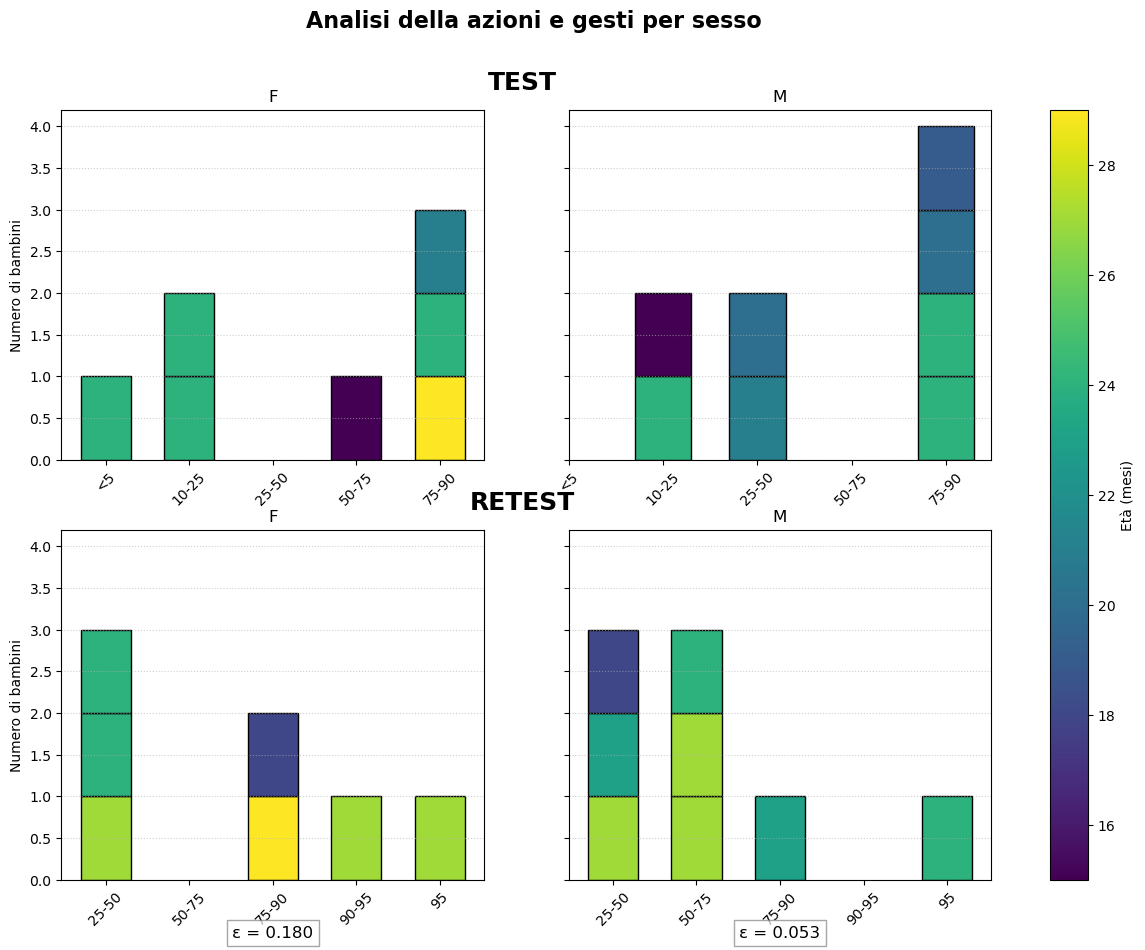

In [7]:
colonna = "AZIONI_E_GESTI"   # <--- CAMBIA SOLO QUESTO
cmap_name = "viridis"

# =======================
# PREPARA TEST E RETEST
# =======================

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
cmap = plt.get_cmap(cmap_name)
norm = mpl.colors.Normalize(vmin=test_clean["Mesi"].min(), vmax=test_clean["Mesi"].max())


test_clean, bins_test, sesso_test = prepara(test, colonna)
retest_clean, bins_retest, sesso_retest = prepara(retest, colonna)

plot_panel(axes[0], sesso_test, bins_test, "TEST",
                  test_clean, retest_clean, colonna, cmap, norm)

plot_panel(axes[1], sesso_retest, bins_retest, "RETEST",
                  test_clean, retest_clean, colonna, cmap, norm)

# colorbar

fig.suptitle("Analisi della " + colonna.lower().replace('_', ' ') + " per sesso", fontsize=16, fontweight='bold', x = 0.5-0.06)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="vertical")
cbar.set_label("Età (mesi)")

# Crea la cartella se non esiste
os.makedirs('grafici0', exist_ok=True)

# Salva il grafico
plt.savefig(f'grafici0/analisi_{colonna}.png', dpi=300, bbox_inches='tight')

plt.show()

In [8]:
# -------------------------
# FUNZIONI PER COSTRUIRE OGNI PANNELLO
# -------------------------
def prepara(df, colonna):
    """
    Pulisce e prepara i dati mantenendo TUTTI i bambini
    tranne quelli con Nan nella colonna analizzata.
    I bambini presenti nel dataset vengono SEMPRE mantenuti nello stack.
    """

    df = df.copy()
    df["Mesi"] = pd.to_numeric(df["Mesi"], errors="coerce")# Converti tutto in stringa
    df[colonna] = df[colonna].replace({"Nan": np.nan, "nan": np.nan, "NaN": np.nan})
    df[colonna] = df[colonna].fillna("mancante")
    df[colonna] = df[colonna].apply(lambda x: str(int(float(x))) if x not in ["mancante"] else x)


    # Normalizzazione stringhe
    df[colonna] = (
        df[colonna]
        .astype(str)
        .str.strip()
        .replace({"Nan": np.nan, "nan": np.nan, "NaN": np.nan})
    )

    # I NaN NON si droppano → li marchiamo
    df[colonna] = df[colonna].fillna("mancante")

    # Ordine logico
    ordine_bin = ["1", "2", "3"]

    presenti = df[colonna].unique().tolist()

    # mantiene solo i bin realmente presenti nei dati
    bins_labels = [b for b in ordine_bin if b in presenti]

    # Costruzione stack per sesso
    sesso_groups = []
    for sesso in ["F", "M"]:
        subset = df[df["Sesso"] == sesso]
        data_stacked = []
        for bin_label in bins_labels:
            mesi_bin = subset[subset[colonna] == bin_label]["Mesi"].dropna().values
            mesi_bin_sorted = np.sort(mesi_bin)[::-1]   # colore per mesi
            data_stacked.append(mesi_bin_sorted)
        sesso_groups.append((sesso, data_stacked))

    return df, bins_labels, sesso_groups





def calcola_epsilon(test_df, retest_df, colonna):
    """
    Calcola la percentuale di miglioramento epsilon per F e M.
    """

    # Valori medi dei bin
    peso_bin = {
        "1": 1,
        "2": 2,
        "3": 3,
        }

    eps_sesso = {}

    for sesso in ["F", "M"]:

        test_s = test_df[test_df["Sesso"] == sesso]
        retest_s = retest_df[retest_df["Sesso"] == sesso]

        # Conta quanti soggetti per bin
        count_test = test_s.groupby(colonna).size()
        count_retest = retest_s.groupby(colonna).size()

        # Bin presenti in entrambi i dataset
        tutti_bin = sorted(set(count_test.index).union(count_retest.index))

        somma = 0
        for b in tutti_bin:
            n_test = count_test.get(b, 0)
            n_retest = count_retest.get(b, 0)
            diff = n_retest - n_test

            w = peso_bin[b] if b in peso_bin else 0
            somma += diff * w

        # N totale per sesso
        Ntot = len(test_s)

        epsilon = somma / (Ntot * 3)

        eps_sesso[sesso] = epsilon

    return eps_sesso

def plot_panel(ax_row, sesso_groups, bins_labels, titolo_riga,
                      test_df, retest_df, colonna, cmap, norm):
    """
    Stampa una riga di due pannelli (F/M), centrando il titolo e
    mantenendo tutti i bambini (eccetto Nan → "Dato assente").
    """

    x = np.arange(len(bins_labels))
    fig = ax_row[0].get_figure()

    # ----- titolo centrato -----
    left = min(ax.get_position().x0 for ax in ax_row)
    right = max(ax.get_position().x1 for ax in ax_row)
    center_x = (left + right) / 2 -0.08

    top_y = max(ax.get_position().y1 for ax in ax_row) + 0.015

    fig.text(center_x, top_y, titolo_riga,
             ha="center", va="bottom",
             fontsize=18, fontweight="bold")

    # ----- epsilon -----
    epsilon = calcola_epsilon(test_df, retest_df, colonna)

    # ----- pannelli F / M -----
    for (label, data_stacked), idx in zip(sesso_groups, range(len(ax_row))):

        ax = ax_row[idx]
        mesi_totali = []

        for bin_idx, mesi_bin_sorted in enumerate(data_stacked):
            mesi_totali.extend(mesi_bin_sorted)
            bottom = 0
            for mese in mesi_bin_sorted:
                ax.bar(
                    bin_idx, 1, width=0.6, bottom=bottom,
                    color=cmap(norm(mese)), edgecolor="black"
                )
                bottom += 1

        ax.set_title(label)
        ax.set_xticks(x)
        ax.set_xticklabels(bins_labels, rotation=45)
        ax.grid(axis='y', linestyle=":", alpha=0.6)

        if idx == 0:
            ax.set_ylabel("Numero di bambini")

        # mostra epsilon solo nei RETEST
        if titolo_riga == "RETEST":
            ax.text(
                0.5, -0.13, f"ε = {epsilon[label]:.3f}",
                transform=ax.transAxes,
                ha="center", va="top",
                fontsize=12,
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray")
            )


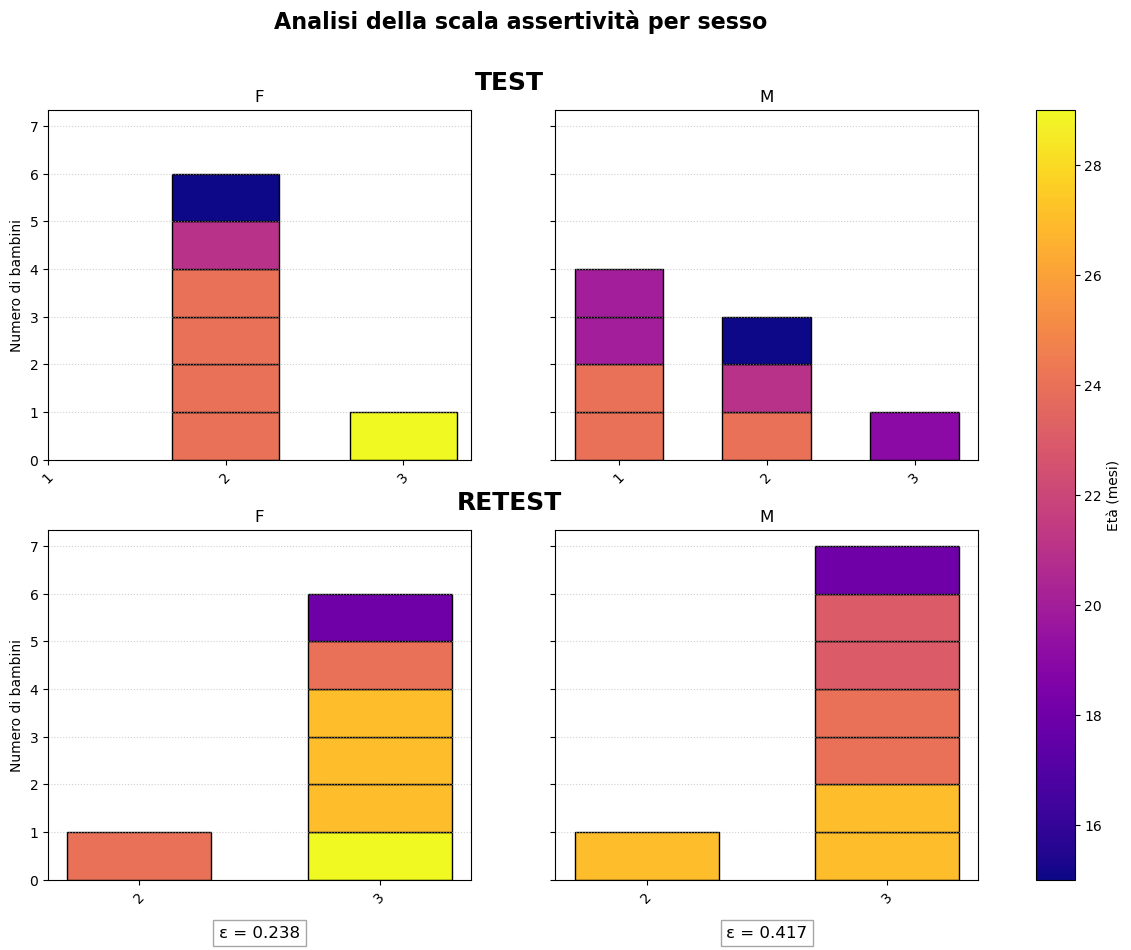

In [9]:
colonna = "Scala_Assertività"   # <--- CAMBIA SOLO QUESTO
cmap_name = "plasma"

# =======================
# PREPARA TEST E RETEST
# =======================

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
cmap = plt.get_cmap(cmap_name)
norm = mpl.colors.Normalize(vmin=test_clean["Mesi"].min(), vmax=test_clean["Mesi"].max())


test_clean, bins_test, sesso_test = prepara(test, colonna)
retest_clean, bins_retest, sesso_retest = prepara(retest, colonna)

plot_panel(axes[0], sesso_test, bins_test, "TEST",
                  test_clean, retest_clean, colonna, cmap, norm)

plot_panel(axes[1], sesso_retest, bins_retest, "RETEST",
                  test_clean, retest_clean, colonna, cmap, norm)

# colorbar

fig.suptitle("Analisi della " + colonna.lower().replace('_', ' ') + " per sesso", fontsize=16, fontweight='bold', x = 0.5-0.06)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="vertical")
cbar.set_label("Età (mesi)")

# Crea la cartella se non esiste
os.makedirs('grafici0', exist_ok=True)

# Salva il grafico
plt.savefig(f'grafici0/analisi_{colonna}.png', dpi=300, bbox_inches='tight')

plt.show()

   Sesso  Mesi COMPRENSIONE_FRASI COMPRENSIONE_PAROLE PAROLE_PRODOTTE  \
0      M    27                 95               25-50           50-75   
1      F    31                 95                  95              95   
2      F    18                 95                  95              95   
3      M    24                 95               50-75           50-75   
4      F    24                 95               75-90           90-95   
5      F    24                Nan                  <5              <5   
6      M    27                 95               50-75           75-90   
7      M    24                 95               75-90              <5   
8      F    27                 95               50-75           90-95   
9      F    27                 95                  95              95   
10     M    23              10-25                  95           50-75   
11     M    23                 95                  95              95   
12     M    27                 95               10-

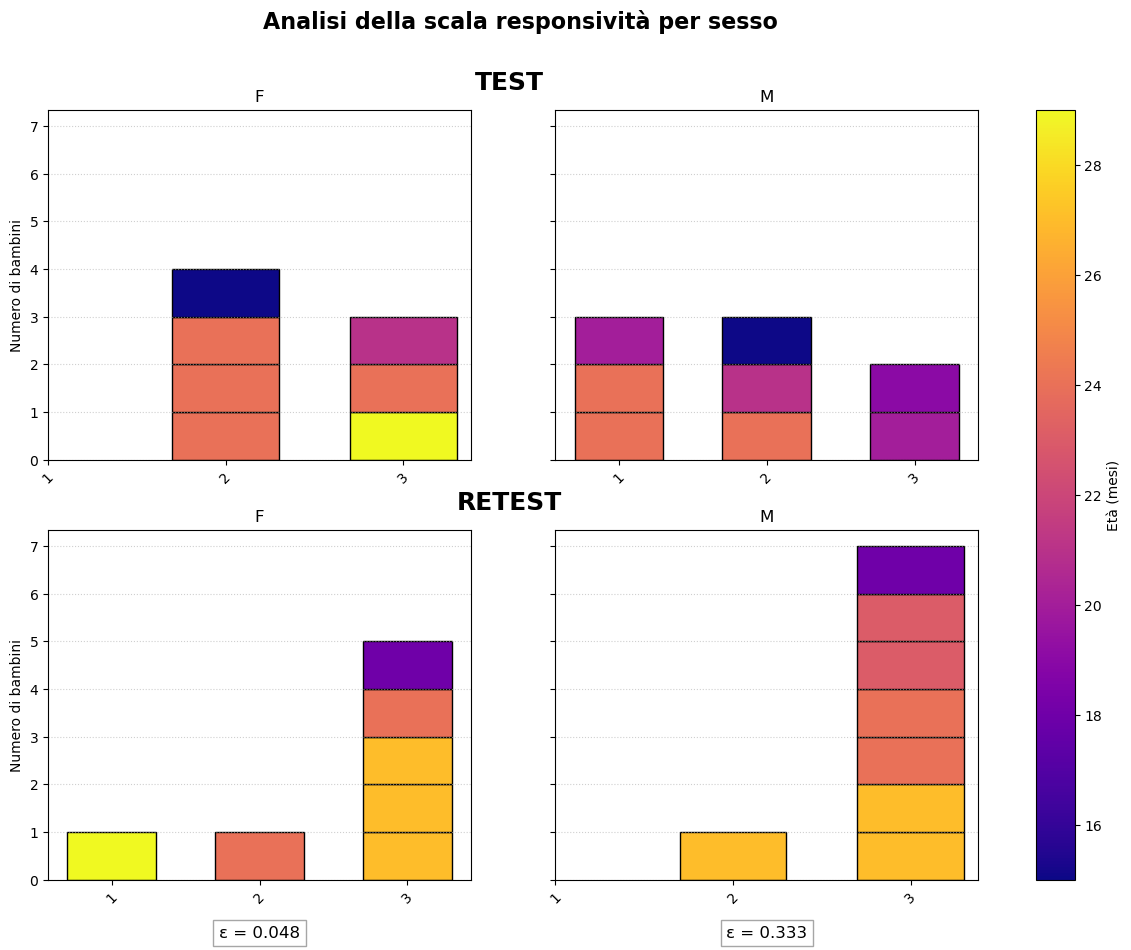

In [10]:
colonna = "Scala_Responsività"   # <--- CAMBIA SOLO QUESTO
cmap_name = "plasma"
# =======================
# PREPARA TEST E RETEST
# =======================

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
cmap = plt.get_cmap(cmap_name)
norm = mpl.colors.Normalize(vmin=test_clean["Mesi"].min(), vmax=test_clean["Mesi"].max())


test_clean, bins_test, sesso_test = prepara(test, colonna)
retest_clean, bins_retest, sesso_retest = prepara(retest, colonna)
print(retest_clean)
plot_panel(axes[0], sesso_test, bins_test, "TEST",
                  test_clean, retest_clean, colonna, cmap, norm)

plot_panel(axes[1], sesso_retest, bins_retest, "RETEST",
                  test_clean, retest_clean, colonna, cmap, norm)

# colorbar

fig.suptitle("Analisi della " + colonna.lower().replace('_', ' ') + " per sesso", fontsize=16, fontweight='bold', x = 0.5-0.06)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="vertical")
cbar.set_label("Età (mesi)")

# Crea la cartella se non esiste
os.makedirs('grafici0', exist_ok=True)

# Salva il grafico
plt.savefig(f'grafici0/analisi_{colonna}.png', dpi=300, bbox_inches='tight')

plt.show()